<a href="https://colab.research.google.com/github/Ali339275/Graph-Attention-Neural-Network/blob/main/GAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS224W - Colab 4**

In Colab 2 we constructed GNN models by using PyTorch Geometric's built in GCN layer, `GCNConv`. In Colab 3 we implemented the  **GraphSAGE** ([Hamilton et al. (2017)](https://arxiv.org/abs/1706.02216)) layer. In this colab you'll use what you've learned and implement a more powerful layer: **GAT** ([Veličković et al. (2018)](https://arxiv.org/abs/1710.10903)). Then we will run our models on the CORA dataset, which is a standard citation network benchmark dataset.

**Note**: Make sure to **sequentially run all the cells in each section** so that the intermediate variables / packages will carry over to the next cell

Have fun and good luck on Colab 4 :)

# Device
We recommend using a GPU for this Colab.

Please click `Runtime` and then `Change runtime type`. Then set the `hardware accelerator` to **GPU**.

## Installation

In [ ]:

# Install torch geometric
import os
import torch

if 'IS_GRADESCOPE_ENV' not in os.environ:
  !pip install torch==2.4.0


# Install torch geometric
if 'IS_GRADESCOPE_ENV' not in os.environ:
  # Clean uninstall first
  !pip uninstall -y torch-geometric torch-sparse torch-scatter torch-cluster torch-spline-conv pyg-lib

  torch_version = str(torch.__version__)
  scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
  sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
  !pip install torch-scatter -f $scatter_src
  !pip install torch-sparse -f $sparse_src
  !pip install torch-geometric
  !pip install ogb

Looking in links: https://pytorch-geometric.com/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 99.6 MB/s eta 0:00:00
Looking in links: https://pytorch-geometric.com/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 81.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
import torch_geometric
torch_geometric.__version__

'2.7.0'

# 1) GNN Layers

## Implementing Layer Modules

In Colab 2, we implemented a GCN model for node and graph classification tasks. However, for that notebook we took advantage of PyG's built in GCN module. For Colabs 3 and 4, we provide a build upon a general Graph Neural Network Stack, into which we will be able to plugin our own module implementations: GraphSAGE and GAT.

We will then use our layer implemenations to complete node classification on the CORA dataset, a standard citation network benchmark. In this dataset, nodes correspond to documents and edges correspond to undirected citations. Each node or document in the graph is assigned a class label and features based on the documents binarized bag-of-words representation. Specifically, the Cora graph has 2708 nodes, 5429 edges, 7 prediction classes, and 1433 features per node.

## GNN Stack Module

Below is the implementation of a general GNN stack, where we can plugin any GNN layer, such as **GraphSage**, **GAT**, etc. This module is provided for you. Your implementations of the **GraphSage** and **GAT** layers will function as components in the GNNStack Module.

In [ ]:
import torch
import torch_scatter
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric.nn as pyg_nn
import torch_geometric.utils as pyg_utils

from torch import Tensor
from typing import Union, Tuple, Optional
from torch_geometric.typing import (OptPairTensor, Adj, Size, NoneType,
                                    OptTensor)

from torch.nn import Parameter, Linear
from torch_sparse import SparseTensor, set_diag
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import remove_self_loops, add_self_loops, softmax, degree

class GNNStack(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, args, emb=False):
        super(GNNStack, self).__init__()
        conv_model = self.build_conv_model(args.model_type)
        self.convs = nn.ModuleList()
        self.convs.append(conv_model(input_dim, hidden_dim))
        assert (args.num_layers >= 1), 'Number of layers is not >=1'
        for l in range(args.num_layers-1):
            self.convs.append(conv_model(args.heads * hidden_dim, hidden_dim))

        # post-message-passing
        self.post_mp = nn.Sequential(
            nn.Linear(args.heads * hidden_dim, hidden_dim), nn.Dropout(args.dropout),
            nn.Linear(hidden_dim, output_dim))

        self.dropout = args.dropout
        self.num_layers = args.num_layers

        self.emb = emb

    def build_conv_model(self, model_type):
        if model_type == 'GraphSage':
            return GraphSage
        elif model_type == 'GAT':
            # When applying GAT with num heads > 1, you need to modify the
            # input and output dimension of the conv layers (self.convs),
            # to ensure that the input dim of the next layer is num heads
            # multiplied by the output dim of the previous layer.
            # HINT: In case you want to play with multiheads, you need to change the for-loop that builds up self.convs to be
            # self.convs.append(conv_model(hidden_dim * num_heads, hidden_dim)),
            # and also the first nn.Linear(hidden_dim * num_heads, hidden_dim) in post-message-passing.
            return GAT

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout,training=self.training)

        x = self.post_mp(x)

        if self.emb == True:
            return x

        return F.log_softmax(x, dim=1)

    def loss(self, pred, label):
        return F.nll_loss(pred, label)

## Creating Our Own Message Passing Layer

Now let's start implementing our own message passing layers! Working through this part will help us become acutely familiar with the behind the scenes work of implementing Pytorch Message Passing Layers, allowing us to build our own GNN models. To do so, we will work with and implement 3 critcal functions needed to define a PyG Message Passing Layer: `forward`, `message`, and `aggregate`.

Before diving head first into the coding details, let us quickly review the key components of the message passing process. To do so, we will focus on a single round of messsage passing with respect to a single central node $x$. Before message passing, $x$ is associated with a feature vector $x^{l-1}$, and the goal of message passing is to update this feature vector as $x^l$. To do so, we implement the following steps: 1) each neighboring node $v$ passes its current message $v^{l-1}$ across the edge $(x, v)$ - 2) for the node $x$, we aggregate all of the messages of the neighboring nodes (for example through a sum or mean) - and 3) we transform the aggregated information by for example applying linear and non-linear transformations. Altogether, the message passing process is applied such that every node $u$ in our graph updates its embedding by acting as the central node $x$ in step 1-3 described above.

Now, we extending this process to that of a single message passing layer, the job of a message passing layer is to update the current feature representation or embedding of each node in a graph by propagating and transforming information within the graph. Overall, the general paradigm of a message passing layers is: 1) pre-processing -> 2) **message passing** / propagation -> 3) post-processing.

The `forward` fuction that we will implement for our message passing layer captures this execution logic. Namely, the `forward` function handles the pre and post-processing of node features / embeddings, as well as initiates message passing by calling the `propagate` function.


The `propagate` function encapsulates the message passing process! It does so by calling three important functions: 1) `message`, 2) `aggregate`, and 3) `update`. Our implementation will vary slightly from this, as we will not explicitly implement `update`, but instead place the logic for updating node embeddings after message passing and within the `forward` function. To be more specific, after information is propagated (message passing), we can further transform the node embeddings outputed by `propagate`. Therefore, the output of `forward` is exactly the node embeddings after one GNN layer.

Lastly, before starting to implement our own layer, let us dig a bit deeper into each of the functions described above:

1.

```
def propagate(edge_index, x=(x_i, x_j), extra=(extra_i, extra_j), size=size):
```
Calling `propagate` initiates the message passing process. Looking at the function parameters, we highlight a couple of key parameters.

  - `edge_index` is passed to the forward function and captures the edge structure of the graph.
  - `x=(x_i, x_j)` represents the node features that will be used in message passing. In order to explain why we pass the tuple `(x_i, x_j)`, we first look at how our edges are represented. For every edge $(i, j) \in E$, we can differentiate $i$ as the source or central node ($x_{central}$) and j as the neighboring node ($x_{neighbor}$).
  
    Taking the example of message passing above, for a central node $u$ we will aggregate and transform all of the messages associated with the nodes $v$ s.t. $(u, v) \in E$ (i.e. $v \in N_{u}$). Thus we see, the subscripts `_i` and `_j` allow us to specifcally differenciate features associated with central nodes (i.e. nodes  recieving message information) and neighboring nodes (i.e. nodes passing messages).

    This is definitely a somewhat confusing concept; however, one key thing to remember / wrap your head around is that depending on the perspective, a node $x$ acts as a central node or a neighboring node. In fact, in undirected graphs we store both edge directions (i.e. $(i, j)$ and $(j, i)$). From the central node perspective, `x_i`, x is collecting neighboring information to update its embedding. From a neighboring node perspective, `x_j`, x is passing its message information along the edge connecting it to a different central node.

  - `extra=(extra_i, extra_j)` represents additional information that we can associate with each node beyond its current feature embedding. In fact, we can include as many additional parameters of the form `param=(param_i, param_j)` as we would like. Again, we highlight that indexing with `_i` and `_j` allows us to differentiate central and neighboring nodes.

  The output of the `propagate` function is a matrix of node embeddings after the message passing process and has shape $[N, d]$.

2.
```
def message(x_j, ...):
```
The `message` function is called by propagate and constructs the messages from
neighboring nodes $j$ to central nodes $i$ for each edge $(i, j)$ in *edge_index*. This function can take any argument that was initially passed to `propagate`. Furthermore, we can again differentiate central nodes and neighboring nodes by appending `_i` or `_j` to the variable name, .e.g. `x_i` and `x_j`. Looking more specifically at the variables, we have:

  - `x_j` represents a matrix of feature embeddings for all neighboring nodes passing their messages along their respective edge (i.e. all nodes $j$ for edges $(i, j) \in E$). Thus, its shape is $[|E|, d]$!
  - In implementing GAT we will see how to access additional variables passed to propagate

  Critically, we see that the output of the `message` function is a matrix of neighboring node embeddings ready to be aggregated, having shape $[|E|, d]$.

3.
```
def aggregate(self, inputs, index, dim_size = None):
```
Lastly, the `aggregate` function is used to aggregate the messages from neighboring nodes. Looking at the parameters we highlight:

  - `inputs` represents a matrix of the messages passed from neighboring nodes (i.e. the output of the `message` function).
  - `index` has the same shape as `inputs` and tells us the central node that corresponding to each of the rows / messages $j$ in the `inputs` matrix. Thus, `index` tells us which rows / messages to aggregate for each central node.

  The output of `aggregate` is of shape $[N, d]$.


For additional resources refer to the PyG documentation for implementing custom message passing layers: https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html

## GAT Implementation

Attention mechanisms have become the state-of-the-art in many sequence-based tasks such as machine translation and learning sentence representations. One of the major benefits of attention-based mechanisms is their ability to focus on the most relevant parts of the input to make decisions. In this problem, we will see how attention mechanisms can be used to perform node classification over graph-structured data through the usage of Graph Attention Networks (GATs) ([Veličković et al. (2018)](https://arxiv.org/abs/1710.10903)).

The building block of the Graph Attention Network is the graph attention layer, which is a variant of the aggregation function. Let $N$ be the number of nodes and $F$ be the dimension of the feature vector for each node. The input to each graph attentional layer is a set of node features: $\mathbf{h} = \{\overrightarrow{h_1}, \overrightarrow{h_2}, \dots, \overrightarrow{h_N}$\}, $\overrightarrow{h_i} \in R^F$. The output of each graph attentional layer is a new set of node features, which may have a new dimension $F'$: $\mathbf{h'} = \{\overrightarrow{h_1'}, \overrightarrow{h_2'}, \dots, \overrightarrow{h_N'}\}$, with $\overrightarrow{h_i'} \in \mathbb{R}^{F'}$.

We will now describe how this transformation is performed for each graph attention layer. First, a shared linear transformation parametrized by the weight matrix $\mathbf{W} \in \mathbb{R}^{F' \times F}$ is applied to every node.

Next, we perform self-attention on the nodes. We use a shared attention function $a$:
\begin{equation}
a : \mathbb{R}^{F'} \times \mathbb{R}^{F'} \rightarrow \mathbb{R}.
\end{equation}

that computes the attention coefficients capturing the importance of node $j$'s features to node $i$:
\begin{equation}
e_{ij} = a(\mathbf{W_l}\overrightarrow{h_i}, \mathbf{W_r} \overrightarrow{h_j})
\end{equation}

The most general formulation of self-attention allows every node to attend to all other nodes which drops all structural information. However, to utilize graph structure in the attention mechanisms, we use **masked attention**. In masked attention, we only compute attention coefficients $e_{ij}$ for nodes $j \in N_i$ where $N_i$ is some neighborhood of node $i$ in the graph.

To easily compare coefficients across different nodes, we normalize the coefficients across $j$ using a softmax function:
\begin{equation}
\alpha_{ij} = \text{softmax}_j(e_{ij}) = \frac{\exp(e_{ij})}{\sum_{k \in N_i} \exp(e_{ik})}
\end{equation}

For this problem, our attention mechanism $a$ will be a single-layer feedforward neural network parametrized by a weight vectors $\overrightarrow{a_l} \in \mathbb{R}^{F'}$ and $\overrightarrow{a_r} \in \mathbb{R}^{F'}$, followed by a LeakyReLU nonlinearity (with negative input slope 0.2). Let $\cdot^T$ represent transposition and $||$ represent concatenation. The coefficients computed by our attention mechanism may be expressed as:

\begin{equation}
\alpha_{ij} = \frac{\exp\Big(\text{LeakyReLU}\Big(\overrightarrow{a_l}^T \mathbf{W_l} \overrightarrow{h_i} + \overrightarrow{a_r}^T\mathbf{W_r}\overrightarrow{h_j}\Big)\Big)}{\sum_{k\in N_i} \exp\Big(\text{LeakyReLU}\Big(\overrightarrow{a_l}^T \mathbf{W_l} \overrightarrow{h_i} + \overrightarrow{a_r}^T\mathbf{W_r}\overrightarrow{h_k}\Big)\Big)}
\end{equation}

For the following questions, we denote `alpha_l` = $\alpha_l = [...,\overrightarrow{a_l}^T \mathbf{W_l} \overrightarrow{h_i},...] \in R^n$ and `alpha_r` = $\alpha_r = [..., \overrightarrow{a_r}^T \mathbf{W_r} \overrightarrow{h_j}, ...] \in R^n$.


At every layer of GAT, after the attention coefficients are computed for that layer, the aggregation function can be computed by a weighted sum of neighborhood messages, where weights are specified by $\alpha_{ij}$.

Now, we use the normalized attention coefficients to compute a linear combination of the features corresponding to them. These aggregated features will serve as the final output features for every node.

\begin{equation}
h_i' = \sum_{j \in N_i} \alpha_{ij} \mathbf{W_r} \overrightarrow{h_j}.
\end{equation}

At this point, we have covered a lot of information! Before reading further about multi-head attention, we encourage you to go again through the excersize of thinking about what components of the attention mechanism correspond with the different functions: 1) `forward`, 2) `message`, and 3 `aggregate`.

- Hint 1: Our aggregation is very similar to that of GraphSage except now we are using sum aggregation
- Hint 2: The terms we aggregate over again represent the individual message that each neighbor node j sends. Thus, we see that $\alpha_{ij}$ is part of the message each node sends and is thus computed during the message step. This makes sense since an attention weight is associated with each edge in the graph.
- Hint 3: Look at the terms in the definition of $\alpha_{ij}$. What values do we want to pre-process and pass as parameters to the `propagate` function. The parameters of `message(..., x_j, alpha_j, alpha_i, ...)` should give a good hint.  

### Multi-Head Attention
To stabilize the learning process of self-attention, we use multi-head attention. To do this we use $K$ independent attention mechanisms, or ``heads'' compute output features as in the above equations. Then, we concatenate these output feature representations:

\begin{equation}
    \overrightarrow{h_i}' = ||_{k=1}^K \Big(\sum_{j \in N_i} \alpha_{ij}^{(k)} \mathbf{W_r}^{(k)} \overrightarrow{h_j}\Big)
\end{equation}

where $||$ is concentation, $\alpha_{ij}^{(k)}$ are the normalized attention coefficients computed by the $k$-th attention mechanism $(a^k)$, and $\mathbf{W}^{(k)}$ is the corresponding input linear transformation's weight matrix. Note that for this setting, $\mathbf{h'} \in \mathbb{R}^{KF'}$.

In [ ]:
class GAT(MessagePassing):

    def __init__(self, in_channels, out_channels, heads = 2,
                 negative_slope = 0.2, dropout = 0., **kwargs):
        super(GAT, self).__init__(node_dim=0, **kwargs)

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.negative_slope = negative_slope
        self.dropout = dropout

        self.lin_l = None
        self.lin_r = None
        self.att_l = None
        self.att_r = None

        ############################################################################
        # TODO: Your code here!
        # Define the layers needed for the message functions below.
        # self.lin_l is the linear transformation that you apply to embeddings
        # BEFORE message passing.
        #
        # Pay attention to dimensions of the linear layers, since we're using
        # multi-head attention.
        # Our implementation is ~1 lines, but don't worry if you deviate from this.

        ############################################################################

        self.lin_l = nn.Linear(in_channels, heads * out_channels, bias=False)

        self.lin_r = self.lin_l

        ############################################################################
        # TODO: Your code here!
        # Define the attention parameters \overrightarrow{a_l/r}^T in the above intro.
        # You have to deal with multi-head scenarios.
        # Use nn.Parameter instead of nn.Linear
        # Our implementation is ~2 lines, but don't worry if you deviate from this.

        ############################################################################

        # nn.Parameter, define it as trainable weight optimized in backPropagation
        self.att_l = nn.Parameter(torch.Tensor(1, heads, out_channels))
        self.att_r = nn.Parameter(torch.Tensor(1, heads, out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_l.weight)
        nn.init.xavier_uniform_(self.lin_r.weight)
        nn.init.xavier_uniform_(self.att_l)
        nn.init.xavier_uniform_(self.att_r)

    def forward(self, x, edge_index, size = None):

        H, C = self.heads, self.out_channels

        ############################################################################
        # TODO: Your code here!
        # Implement message passing, as well as any pre- and post-processing (our update rule).
        # 1. First apply linear transformation to node embeddings, and split that
        #    into multiple heads. We use the same representations for source and
        #    target nodes, but apply different linear weights (W_l and W_r)
        # 2. Calculate alpha vectors for central nodes (alpha_l) and neighbor nodes (alpha_r).
        # 3. Call propagate function to conduct the message passing.
        #    3.1 Remember to pass alpha = (alpha_l, alpha_r) as a parameter.
        #    3.2 See there for more information: https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html
        # 4. Transform the output back to the shape of [N, H * C].
        # Our implementation is ~5 lines, but don't worry if you deviate from this.


        ############################################################################
        x_l = self.lin_l(x).view(-1, H, C)
        x_r = self.lin_r(x).view(-1, H, C)

        #sum accross attention features so each node get one attention
        alpha_l = (x_l * self.att_l).sum(dim=-1)
        alpha_r = (x_r * self.att_r).sum(dim=-1)

        out = self.propagate(edge_index= edge_index, x=(x_l,x_r), size=size, alpha=(alpha_l, alpha_r))

        out = out.view(-1, H * C)

        return out


    def message(self, x_j, alpha_j, alpha_i, index, ptr, size_i):
      #index tells which node receives each message, target nodes
      #size_i is the number of target nodes



        ############################################################################
        # TODO: Your code here!
        # Implement your message function. Putting the attention in message
        # instead of in update is a little tricky.
        # 1. Calculate the final attention weights using alpha_i and alpha_j,
        #    and apply leaky Relu.
        # 2. Calculate softmax over the neighbor nodes for all the nodes. Use
        #    torch_geometric.utils.softmax instead of the one in Pytorch.
        # 3. Apply dropout to attention weights (alpha).
        # 4. Multiply embeddings and attention weights. As a sanity check, the output
        #    should be of shape [E, H, C].
        # 5. ptr (LongTensor, optional): If given, computes the softmax based on
        #    sorted inputs in CSR representation. You can simply pass it to softmax.
        # 6. size_i: corresponds to the num_nodes variable input to the torch.geometric.softmax method
        # Our implementation is ~4-5 lines, but don't worry if you deviate from this.


        ############################################################################

        alpha_ij = alpha_i + alpha_j
        alpha_ij = F.leaky_relu(alpha_ij, self.negative_slope)

        alpha_ij = torch_geometric.utils.softmax(alpha_ij, index, ptr, size_i)

        alpha_ij = F.dropout(alpha_ij, p=self.dropout, training=self.training)

        out = x_j * alpha_ij.view(-1, self.heads, 1)

        return out


    def aggregate(self, inputs, index, dim_size = None):

        ############################################################################
        # TODO: Your code here!
        # Implement your aggregate function here.
        # See here as how to use torch_scatter.scatter: https://pytorch-scatter.readthedocs.io/en/latest/_modules/torch_scatter/scatter.html
        # Pay attention to "reduce" parameter is different from that in GraphSage.
        # Our implementation is ~1 lines, but don't worry if you deviate from this.

        ############################################################################

        out = torch_scatter.scatter(inputs, index, dim=0, reduce='sum')

        return out

## Building Optimizers

This function has been implemented for you. **For grading purposes please use the default Adam optimizer**, but feel free to play with other types of optimizers on your own.

In [ ]:
import torch.optim as optim

def build_optimizer(args, params):
    weight_decay = args.weight_decay
    filter_fn = filter(lambda p : p.requires_grad, params)
    if args.opt == 'adam':
        optimizer = optim.Adam(filter_fn, lr=args.lr, weight_decay=weight_decay)
    elif args.opt == 'sgd':
        optimizer = optim.SGD(filter_fn, lr=args.lr, momentum=0.95, weight_decay=weight_decay)
    elif args.opt == 'rmsprop':
        optimizer = optim.RMSprop(filter_fn, lr=args.lr, weight_decay=weight_decay)
    elif args.opt == 'adagrad':
        optimizer = optim.Adagrad(filter_fn, lr=args.lr, weight_decay=weight_decay)
    if args.opt_scheduler == 'none':
        return None, optimizer
    elif args.opt_scheduler == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=args.opt_decay_step, gamma=args.opt_decay_rate)
    elif args.opt_scheduler == 'cos':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.opt_restart)
    return scheduler, optimizer

## Training and Testing

Here we provide you with the functions to train and test. **Please do not modify this part for grading purposes.**

In [ ]:
# Functions to load and process ICEWS18 temporal KG dataset, form its raw input to KG representation
# its taken from RE-GCN github

def load_data(dataset, bfs_level=3, relabel=False):
    if dataset in ['aifb', 'mutag', 'bgs', 'am']:
        return knwlgrh.load_entity(dataset, bfs_level, relabel)
    elif dataset in ['FB15k', 'wn18', 'FB15k-237']:
        return knwlgrh.load_link(dataset)
    elif dataset in ['ICEWS18', 'ICEWS14', "GDELT", "SMALL", "ICEWS14s", "ICEWS05-15","YAGO",
                     "WIKI"]:
        return knwlgrh.load_from_local("../data", dataset)
    else:
        raise ValueError('Unknown dataset: {}'.format(dataset))

def split_by_time(data):
    snapshot_list = [] #A list to store snapshots (subsets of triples grouped by time).
    snapshot = [] #A temporary list to store triples for the current timestamp.
    snapshots_num = 0
    latest_t = 0
    for i in range(len(data)):
        t = data[i][3]
        train = data[i]

        if latest_t != t:
            # show snapshot
            latest_t = t
            if len(snapshot):
                snapshot_list.append(np.array(snapshot).copy())
                snapshots_num += 1
            snapshot = []
        snapshot.append(train[:3])

    if len(snapshot) > 0: #append the last snapshot if it contains triples
        snapshot_list.append(np.array(snapshot).copy())
        snapshots_num += 1

    union_num = [1]
    nodes = []
    rels = []
    for snapshot in snapshot_list:
        uniq_v, edges = np.unique((snapshot[:,0], snapshot[:,2]), return_inverse=True)  # relabel
        uniq_r = np.unique(snapshot[:,1])
        edges = np.reshape(edges, (2, -1))
        nodes.append(len(uniq_v))
        rels.append(len(uniq_r)*2)
    print("# Sanity Check:  ave node num : {:04f}, ave rel num : {:04f}, snapshots num: {:04d}, max edges num: {:04d}, min edges num: {:04d}, max union rate: {:.4f}, min union rate: {:.4f}"
          .format(np.average(np.array(nodes)), np.average(np.array(rels)), len(snapshot_list), max([len(_) for _ in snapshot_list]), min([len(_) for _ in snapshot_list]), max(union_num), min(union_num)))
    return snapshot_list


    def build_sub_graph(num_nodes, num_rels, triples, use_cuda, gpu):
    """
    :param node_id: node id in the large graph
    :param num_rels: number of relation
    :param src: relabeled src id
    :param rel: original rel id
    :param dst: relabeled dst id
    :param use_cuda:
    :return:
    """
    def comp_deg_norm(g):
        in_deg = g.in_degrees(range(g.number_of_nodes())).float()
        in_deg[torch.nonzero(in_deg == 0).view(-1)] = 1
        norm = 1.0 / in_deg
        return norm

    src, rel, dst = triples.transpose()
    src, dst = np.concatenate((src, dst)), np.concatenate((dst, src))
    rel = np.concatenate((rel, rel + num_rels))

    g = dgl.DGLGraph()
    g.add_nodes(num_nodes)
    g.add_edges(src, dst)
    norm = comp_deg_norm(g)
    node_id = torch.arange(0, num_nodes, dtype=torch.long).view(-1, 1)
    g.ndata.update({'id': node_id, 'norm': norm.view(-1, 1)})
    g.apply_edges(lambda edges: {'norm': edges.dst['norm'] * edges.src['norm']})
    g.edata['type'] = torch.LongTensor(rel)

    uniq_r, r_len, r_to_e = r2e(triples, num_rels)
    g.uniq_r = uniq_r
    g.r_to_e = r_to_e
    g.r_len = r_len
    if use_cuda:
        g = g.to(gpu)
        g.r_to_e = torch.from_numpy(np.array(r_to_e))
    return g

In [ ]:
import time

import networkx as nx
import numpy as np
import torch
import torch.optim as optim
from tqdm import trange
import pandas as pd
import copy

from torch_geometric.datasets import TUDataset
from torch_geometric.datasets import Planetoid
from torch_geometric.data import DataLoader

import torch_geometric.nn as pyg_nn

import matplotlib.pyplot as plt


def train(dataset, args):

    print("Node task. test set size:", np.sum(dataset[0]['test_mask'].numpy()))
    print()
    test_loader = loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=False)

    # build model
    model = GNNStack(dataset.num_node_features, args.hidden_dim, dataset.num_classes,
                            args)
    scheduler, opt = build_optimizer(args, model.parameters())

    # train
    losses = []
    test_accs = []
    best_acc = 0
    best_model = None
    for epoch in trange(args.epochs, desc="Training", unit="Epochs"):
        total_loss = 0
        model.train()
        for batch in loader:
            opt.zero_grad()
            pred = model(batch)
            label = batch.y
            pred = pred[batch.train_mask]
            label = label[batch.train_mask]
            loss = model.loss(pred, label)
            loss.backward()
            opt.step()
            total_loss += loss.item() * batch.num_graphs
        total_loss /= len(loader.dataset)
        losses.append(total_loss)

        if epoch % 10 == 0:
          test_acc, preds, labels = test(test_loader, model)
          test_accs.append(test_acc)
          if test_acc > best_acc:
            best_acc = test_acc
            best_model = copy.deepcopy(model)
            best_preds = preds
            best_labels = labels
        else:
          test_accs.append(test_accs[-1])

    return test_accs, losses, best_model, best_acc, test_loader, best_preds, best_labels

def test(loader, test_model, is_validation=False, save_model_preds=False, model_type=None):
    test_model.eval()

    correct = 0
    all_preds = []
    all_labels = []

    # Cora is one graph but loader still loops
    for data in loader:
        with torch.no_grad():
            pred = test_model(data).max(dim=1)[1]
            label = data.y

        mask = data.val_mask if is_validation else data.test_mask

        pred = pred[mask]
        label = label[mask]

        all_preds.append(pred.cpu())
        all_labels.append(label.cpu())

        correct += pred.eq(label).sum().item()

    total = 0
    for data in loader.dataset:
        total += torch.sum(data.val_mask if is_validation else data.test_mask).item()

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    if save_model_preds:
        print("Saving Model Predictions for Model Type", model_type)

        df = pd.DataFrame({
            "pred": preds.numpy(),
            "label": labels.numpy()
        })

        df.to_csv('CORA-Node-' + model_type + '.csv', index=False)

    return correct / total, preds, labels

class objectview(object):
    def __init__(self, d):
        self.__dict__ = d


## Let's Start the Training!

We will be working on the CORA dataset on node-level classification.

This part is implemented for you. **For grading purposes, please do not modify the default parameters.** However, feel free to play with different configurations just for fun! Training with default parameters on the GPU runtime should take less than 5 minutes.

**Submit your best accuracy on Gradescope.**

In [ ]:
#Helper function to plot node clusters

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_node_clusters(model, data, labels=None):

    model.eval()

    with torch.no_grad():
        embeddings = model(data)

    embeddings = embeddings.cpu().numpy()

    # reduce to 2D
    tsne = TSNE(n_components=2, random_state=42)
    z = tsne.fit_transform(embeddings)

    if labels is None:
        labels = data.y.cpu().numpy()
    else:
        labels = labels.cpu().numpy()

    plt.figure(figsize=(8,8))
    scatter = plt.scatter(
        z[:,0],
        z[:,1],
        c=labels,
        cmap="tab10",
        s=15
    )

    plt.title("Node Embedding Clusters (Cora)")
    plt.colorbar(scatter)
    plt.show()

/tmp/ipykernel_1108/2830406512.py:24: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=False)


Node task. test set size: 1000



Training: 100%|██████████| 500/500 [00:40<00:00, 12.45Epochs/s]


Maximum test set accuracy: 0.778
Minimum loss: 0.02238805592060089
Saving Model Predictions for Model Type GAT

    pred  true
0      3     3
1      2     2
2      2     2
3      2     2
4      2     2
5      6     0
6      2     2
7      2     2
8      2     2
9      2     2
10     2     2
11     2     2
12     2     2
13     2     2
14     2     2
15     2     2
16     2     2
17     2     2
18     2     2
19     2     2


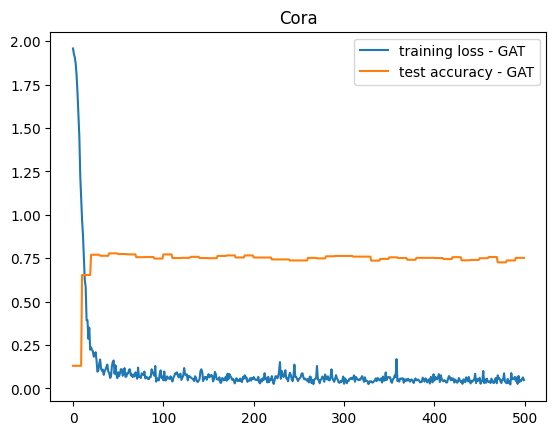

In [ ]:
if 'IS_GRADESCOPE_ENV' not in os.environ:
    for args in [
        {'model_type': 'GAT', 'dataset': 'cora', 'num_layers': 2, 'heads': 1, 'batch_size': 32, 'hidden_dim': 32, 'dropout': 0.5, 'epochs': 500, 'opt': 'adam', 'opt_scheduler': 'none', 'opt_restart': 0, 'weight_decay': 5e-3, 'lr': 0.01},
    ]:
        args = objectview(args)
        for model in ['GAT']:
            args.model_type = model

            # Match the dimension.
            if model == 'GAT':
              args.heads = 2
            else:
              args.heads = 1

            if args.dataset == 'cora':
                dataset = Planetoid(root='/tmp/cora', name='Cora')
            else:
                raise NotImplementedError("Unknown dataset")
            test_accs, losses, best_model, best_acc, test_loader, preds, labels = train(dataset, args)

            print("Maximum test set accuracy: {0}".format(max(test_accs)))
            print("Minimum loss: {0}".format(min(losses)))

            # Run test for our best model to save the predictions!
            test(test_loader, best_model, is_validation=False, save_model_preds=True, model_type=model)
            print()

            plt.title(dataset.name)
            plt.plot(losses, label="training loss" + " - " + args.model_type)
            plt.plot(test_accs, label="test accuracy" + " - " + args.model_type)

            df = pd.DataFrame({
                "pred": preds.numpy(),
                "true": labels.numpy()
            })

            print(df.head(20))

        plt.legend()
        plt.show()


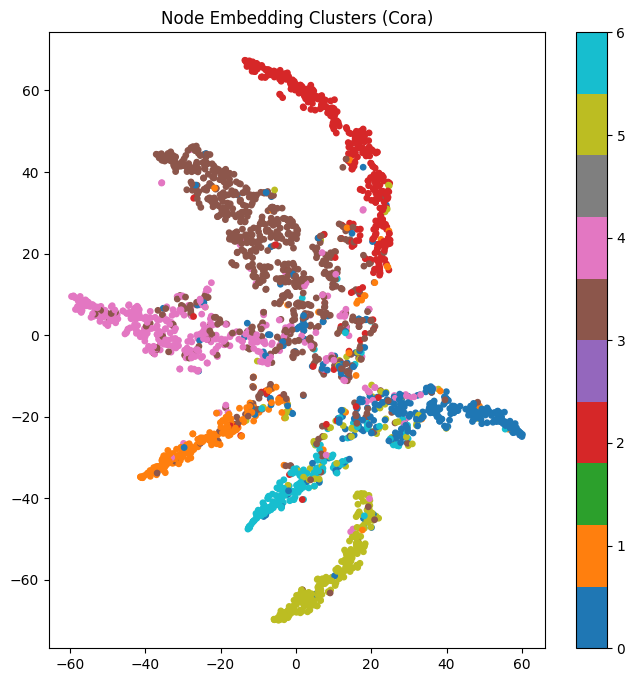

In [ ]:
dataset = Planetoid(root='/tmp/cora', name='Cora')

data = dataset[0]

plot_node_clusters(best_model, data)

## Question 1: What is the maximum accuracy obtained on test set for GAT? (10 points)


Running the training cell above will also save your best GAT model predictions as *CORA-Node-GAT.csv*.  As a sanity check, the accuracy should be at least 0.7. The accuracy will be checked by the Auto-grader, so only the code submission is required.

When you sumbit your assignment, you will have to download this file and attatch it to your submission. As with the Colab 3, please zip this file `CS224W_Colab4.ipynb` and the *.csv* file that's generated! Also, please make sure that the files are name correctly, otherwise the Auto-grader will not be able to find your submission files.
